# Análise exploratória — Preços de Diesel (ANP)

Estatísticas básicas sobre `data/diesel.parquet` (série histórica de preços de combustíveis da ANP), gerado por `download.py` + `convert.py` (ou `main.py`). Usado como proxy de custo de frete no projeto de inflação do PBF no preço do feijão.

As colunas originais do parquet (ex.: `Estado - Sigla`, `Data da Coleta`) têm espaços e traços; nas queries abaixo elas são renomeadas para `snake_case` só no resultado (dataframe em memória), sem alterar o arquivo `diesel.parquet` em si.

In [ ]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

PARQUET_PATH = "data/diesel.parquet"
con = duckdb.connect()


def normalize(column_name: str) -> str:
    """snake_case: minusculas, espacos/tracos viram underscore."""
    return re.sub(r"[-\s]+", "_", column_name.strip().lower())

# Rename Columns

In [ ]:
df_raw = pd.read_parquet(PARQUET_PATH)

## Visão geral

In [2]:
df_base = duckdb.sql(
    f"""
    SELECT 
        "Regiao - Sigla" as regiao_sigla,
        "Estado - Sigla" as estado_sigla,
        "Municipio" as municipio,
        "Revenda" as revenda,
        "CNPJ da Revenda" as cnpj_da_revenda,
        "Nome da Rua" as nome_da_rua,
        "Numero Rua" as numero_da_rua,
        "Complemento" as complemento,
        "Bairro" as bairro,
        "Cep" as cep,
        "Produto" as produto,
        "Data da Coleta" as data_da_coleta,
        "Valor de Venda" as valor_de_venda,
        "Valor de Compra" as valor_de_compra,
        "Unidade de Medida" as unidade_de_medida,
        "Bandeira" as bandeira,
        "file_name" as file_name
    FROM '{PARQUET_PATH}'
    """
).df()

KeyboardInterrupt: 

In [ ]:
overview = duckdb.sql(f"""
    select
        count(*) as total_linhas,
        count(distinct file_name) as arquivos_origem,
        count(distinct \"Estado - Sigla\") as estados,
        count(distinct \"Municipio\") as municipios,
        count(distinct \"Revenda\") as revendas
    from '{PARQUET_PATH}'
""").df()
overview

,total_linhas,arquivos_origem,estados,municipios,revendas
0,25253049,45,27,700,32038


## Qualidade dos dados — valores ausentes por coluna

In [3]:
columns = con.execute(f"describe select * from '{PARQUET_PATH}'").df()["column_name"].tolist()

null_counts_sql = ", ".join(
    f'sum(case when "{col}" is null then 1 else 0 end) as "{normalize(col)}"' for col in columns
)
nulls = con.execute(f"select {null_counts_sql} from '{PARQUET_PATH}'").df().T
nulls.columns = ["valores_ausentes"]
nulls.sort_values("valores_ausentes", ascending=False)

,valores_ausentes
complemento,18570038.0
valor_de_compra,14841064.0
bairro,85603.0
numero_rua,21527.0
bandeira,9115.0
unidade_de_medida,9115.0
valor_de_venda,9115.0
data_da_coleta,9115.0
produto,9114.0
regiao_sigla,9114.0


## Cobertura temporal

In [4]:
date_range = con.execute(f"""
    select min(\"Data da Coleta\") as data_min, max(\"Data da Coleta\") as data_max
    from '{PARQUET_PATH}'
""").df()
date_range

,data_min,data_max
0,2004-05-10,2026-06-30


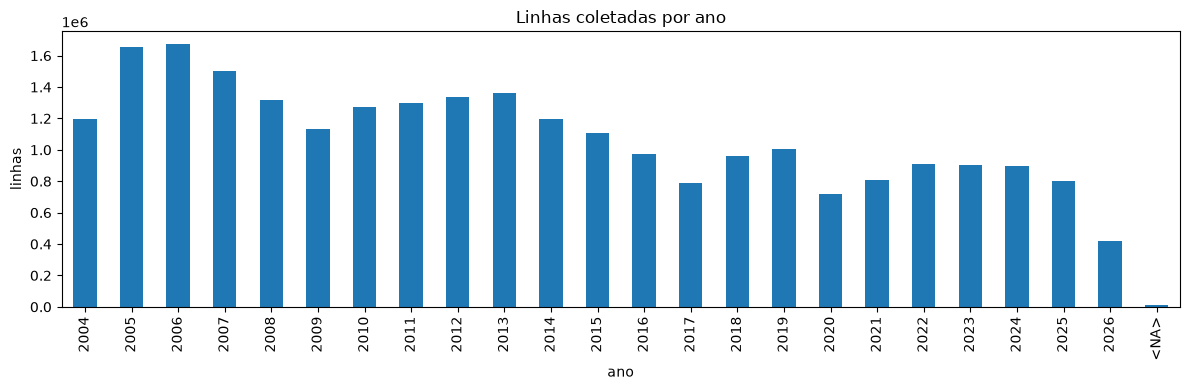

In [5]:
rows_per_year = con.execute(f"""
    select year(\"Data da Coleta\") as ano, count(*) as linhas
    from '{PARQUET_PATH}'
    group by 1
    order by 1
""").df()

rows_per_year.plot(x="ano", y="linhas", kind="bar", figsize=(12, 4), legend=False, title="Linhas coletadas por ano")
plt.ylabel("linhas")
plt.tight_layout()
plt.show()

## Produtos

In [6]:
by_product = con.execute(f"""
    select coalesce(\"Produto\", '(nulo)') as produto, count(*) as linhas
    from '{PARQUET_PATH}'
    group by 1
    order by 2 desc
""").df()
by_product

,produto,linhas
0,GASOLINA,8134845
1,ETANOL,7468181
2,DIESEL,5697313
3,DIESEL S10,2454333
4,GASOLINA ADITIVADA,953807
5,GNV,490960
6,DIESEL S50,44495
7,(nulo),9114
8,ETANO,1


## Preço de venda — estatísticas por tipo de diesel

Filtrando os produtos `DIESEL`, `DIESEL S10` e `DIESEL S50` (a variante `ETANO` é tratada como possível erro de digitação de `ETANOL` e ignorada aqui).

In [7]:
diesel_stats = con.execute(f"""
    select
        \"Produto\" as produto,
        count(*) as n,
        round(avg(\"Valor de Venda\"), 3) as preco_medio,
        round(median(\"Valor de Venda\"), 3) as preco_mediano,
        round(stddev(\"Valor de Venda\"), 3) as desvio_padrao,
        round(min(\"Valor de Venda\"), 3) as preco_min,
        round(max(\"Valor de Venda\"), 3) as preco_max
    from '{PARQUET_PATH}'
    where \"Produto\" like 'DIESEL%'
    group by 1
    order by 1
""").df()
diesel_stats

,produto,n,preco_medio,preco_mediano,desvio_padrao,preco_min,preco_max
0,DIESEL,5697313,2.562,2.070,1.236,1.020,9.45
1,DIESEL S10,2454333,4.248,3.619,1.496,1.938,9.99
2,DIESEL S50,44495,2.172,2.160,0.125,1.599,2.95


## Série temporal — preço médio mensal do diesel

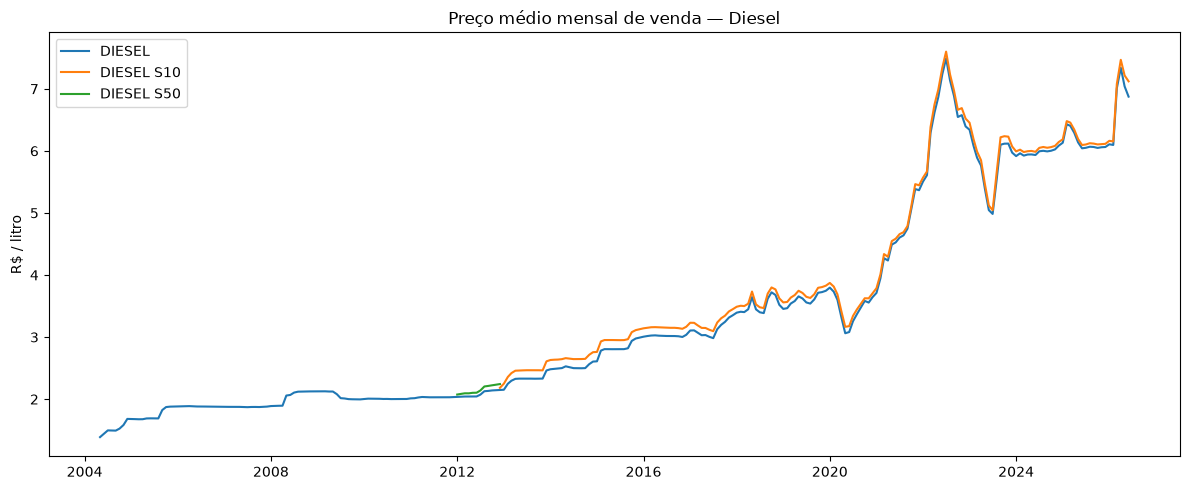

In [8]:
monthly_price = con.execute(f"""
    select
        date_trunc('month', \"Data da Coleta\") as mes,
        \"Produto\" as produto,
        avg(\"Valor de Venda\") as preco_medio
    from '{PARQUET_PATH}'
    where \"Produto\" like 'DIESEL%'
    group by 1, 2
    order by 1
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
for produto, group in monthly_price.groupby("produto"):
    ax.plot(group["mes"], group["preco_medio"], label=produto)
ax.set_title("Preço médio mensal de venda — Diesel")
ax.set_ylabel("R$ / litro")
ax.legend()
plt.tight_layout()
plt.show()

## Distribuição geográfica — preço médio do diesel comum por estado

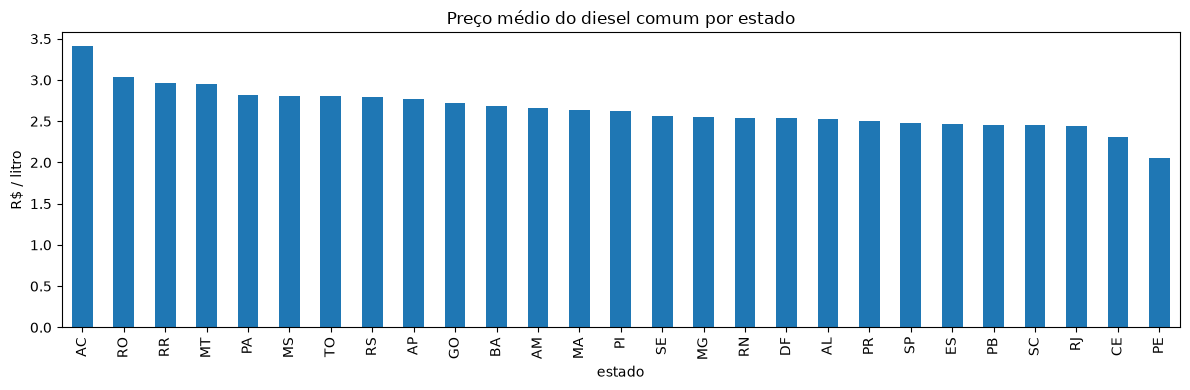

In [9]:
by_state = con.execute(f"""
    select \"Estado - Sigla\" as estado, avg(\"Valor de Venda\") as preco_medio, count(*) as n
    from '{PARQUET_PATH}'
    where \"Produto\" = 'DIESEL'
    group by 1
    order by 2 desc
""").df()

by_state.plot(x="estado", y="preco_medio", kind="bar", figsize=(12, 4), legend=False, title="Preço médio do diesel comum por estado")
plt.ylabel("R$ / litro")
plt.tight_layout()
plt.show()